In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import hdbscan
import umap

In [2]:
overall_df = pd.read_csv("2015_to_2023_full_preprocessed_data_set.csv")

In [3]:
cluster_cols = ["Age9", "Gend3", "Eth7", "Disab3", "NSSEC5", "Educ6"]

overall_df[cluster_cols].isna().mean().sort_values()

Gend3     0.002203
Age9      0.009748
Educ6     0.064289
NSSEC5    0.064754
Disab3    0.067088
Eth7      0.067553
dtype: float64

In [4]:
for col in cluster_cols:
    print(overall_df[col].value_counts(dropna=False))

Age9
4.0    28413
3.0    25531
5.0    23413
6.0    20830
7.0    16949
2.0    11236
8.0     7824
9.0     2029
NaN     1341
Name: count, dtype: int64
Gend3
2.0    76885
1.0    59903
3.0      475
NaN      303
Name: count, dtype: int64
Eth7
1.0    70257
2.0    21004
3.0    17757
NaN     9293
4.0     8696
6.0     4160
7.0     3709
5.0     2690
Name: count, dtype: int64
Disab3
3.0    89847
2.0    19821
1.0    18669
NaN     9229
Name: count, dtype: int64
NSSEC5
1.0    78747
2.0    23381
4.0    12712
3.0    12487
NaN     8908
5.0     1331
Name: count, dtype: int64
Educ6
1.0    85385
3.0    14502
2.0    14167
NaN     8844
6.0     7676
5.0     5056
4.0     1936
Name: count, dtype: int64


In [5]:
cluster_df = overall_df[cluster_cols + ["year"]].dropna().copy()

In [6]:
X = pd.get_dummies(cluster_df[cluster_cols], drop_first=False)

In [7]:
reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, metric="hamming", random_state=42)

embedding = reducer.fit_transform(X)

c:\Users\Matt_\OneDrive\London Sport Group Project\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for hamming distance metric; inverse_transform will be unavailable
  warn(
c:\Users\Matt_\OneDrive\London Sport Group Project\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\Matt_\OneDrive\London Sport Group Project\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\Matt_\OneDrive\London Sport Group Project\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to 

In [8]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=1000, min_samples=25, prediction_data=True)

labels = clusterer.fit_predict(embedding) # type: ignore

cluster_df["cluster"] = labels

cluster_df["cluster"].value_counts()

cluster
-1     45468
 17    28366
 13     5722
 11     4986
 14     3469
 10     2788
 1      2367
 4      1873
 0      1473
 16     1397
 12     1222
 8      1212
 6      1155
 7      1134
 9      1128
 15     1113
 2      1112
 5      1097
 3      1071
Name: count, dtype: int64

In [9]:
noise_points = (cluster_df["cluster"] == -1).sum()

cluster_sizes = (cluster_df.loc[cluster_df["cluster"] != -1, "cluster"].value_counts())

cluster_summary = pd.DataFrame({"Metric": ["Observations", "Clusters", "Noise points", "Largest cluster", "Smallest cluster", "Mean cluster size"],
                        "Value": [
                            len(cluster_df),
                            cluster_df["cluster"].nunique() - (1 if -1 in cluster_df["cluster"].unique() else 0),
                            noise_points,
                            cluster_sizes.max(),
                            cluster_sizes.min(),
                            round(cluster_sizes.mean(), 1)]})

print(cluster_summary)

              Metric     Value
0       Observations  108153.0
1           Clusters      18.0
2       Noise points   45468.0
3    Largest cluster   28366.0
4   Smallest cluster    1071.0
5  Mean cluster size    3482.5


In [10]:
noise_pct = ((cluster_df["cluster"] == -1).mean() * 100)

print(f"Noise percentage: {noise_pct:.2f}%")

Noise percentage: 42.04%


In [11]:
cluster_years = pd.crosstab(cluster_df["cluster"], cluster_df["year"], normalize="columns")

print(cluster_years.round(3))

year     2015/16  2016/17  2017/18  2018/19  2019/20  2020/21  2021/22  \
cluster                                                                  
-1         0.429    0.407    0.437    0.426    0.427    0.414    0.422   
 0         0.017    0.014    0.016    0.013    0.011    0.012    0.012   
 1         0.019    0.018    0.021    0.022    0.023    0.023    0.023   
 2         0.009    0.010    0.011    0.012    0.011    0.010    0.009   
 3         0.000    0.064    0.000    0.000    0.000    0.000    0.000   
 4         0.019    0.015    0.017    0.018    0.020    0.017    0.016   
 5         0.010    0.010    0.010    0.011    0.012    0.010    0.010   
 6         0.009    0.010    0.011    0.011    0.012    0.011    0.011   
 7         0.012    0.010    0.010    0.010    0.010    0.010    0.011   
 8         0.012    0.010    0.011    0.011    0.012    0.012    0.010   
 9         0.010    0.009    0.012    0.010    0.012    0.011    0.010   
 10        0.029    0.024    0.027    

In [12]:
for col in cluster_cols:

    print(f"\n{'='*60}")
    print(col)

    print(pd.crosstab( cluster_df["cluster"], cluster_df[col], normalize="index").round(3))


Age9
Age9       2.0    3.0    4.0    5.0    6.0    7.0    8.0    9.0
cluster                                                        
-1       0.056  0.226  0.235  0.170  0.177  0.137  0.000  0.000
 0       0.060  0.000  0.000  0.236  0.705  0.000  0.000  0.000
 1       0.042  0.176  0.151  0.136  0.228  0.267  0.000  0.000
 2       0.000  0.080  0.000  0.158  0.311  0.451  0.000  0.000
 3       0.000  0.000  0.000  0.000  0.000  0.000  0.774  0.226
 4       0.120  0.378  0.227  0.147  0.032  0.096  0.000  0.000
 5       0.000  0.148  0.074  0.778  0.000  0.000  0.000  0.000
 6       0.000  0.070  0.000  0.547  0.306  0.077  0.000  0.000
 7       0.220  0.126  0.000  0.000  0.042  0.611  0.000  0.000
 8       0.129  0.200  0.083  0.000  0.240  0.348  0.000  0.000
 9       0.000  0.175  0.340  0.486  0.000  0.000  0.000  0.000
 10      0.142  0.292  0.069  0.165  0.202  0.131  0.000  0.000
 11      0.045  0.172  0.432  0.286  0.044  0.022  0.000  0.000
 12      0.000  0.259  0.741  0.00

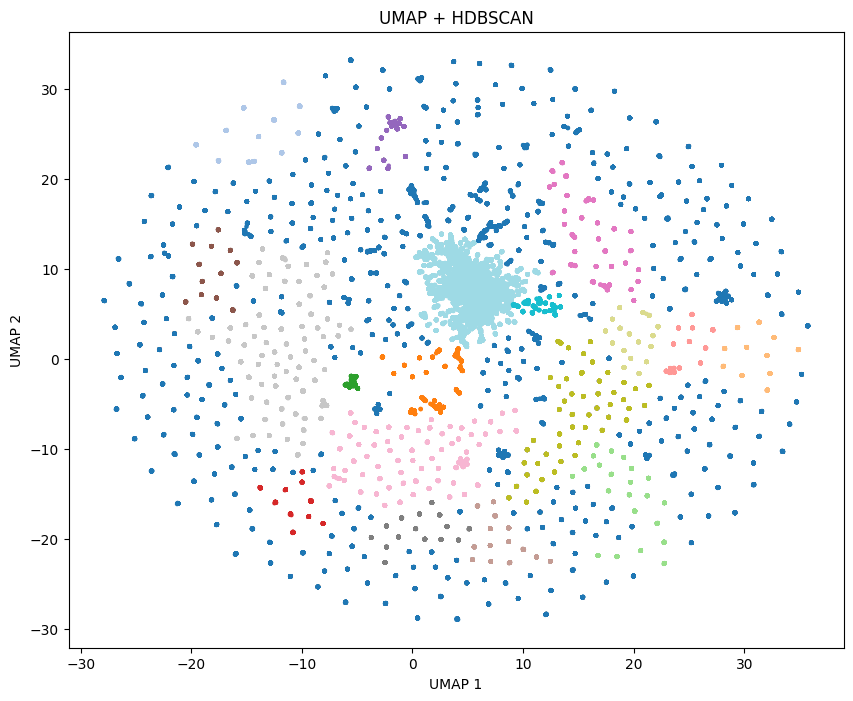

In [13]:
plt.figure(figsize=(10,8))

plt.scatter(embedding[:,0], embedding[:,1], c=cluster_df["cluster"], cmap="tab20", s=5) # type: ignore

plt.title("UMAP + HDBSCAN")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")

plt.show()